In [4]:

from google.colab import files

uploaded = files.upload()

Saving Student_Performance.csv to Student_Performance.csv


In [5]:

import pandas as pd

In [7]:

df = pd.read_csv("Student_Performance.csv")

In [8]:

df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [9]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [10]:

df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [11]:

df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [12]:

df.duplicated().sum()

np.int64(127)

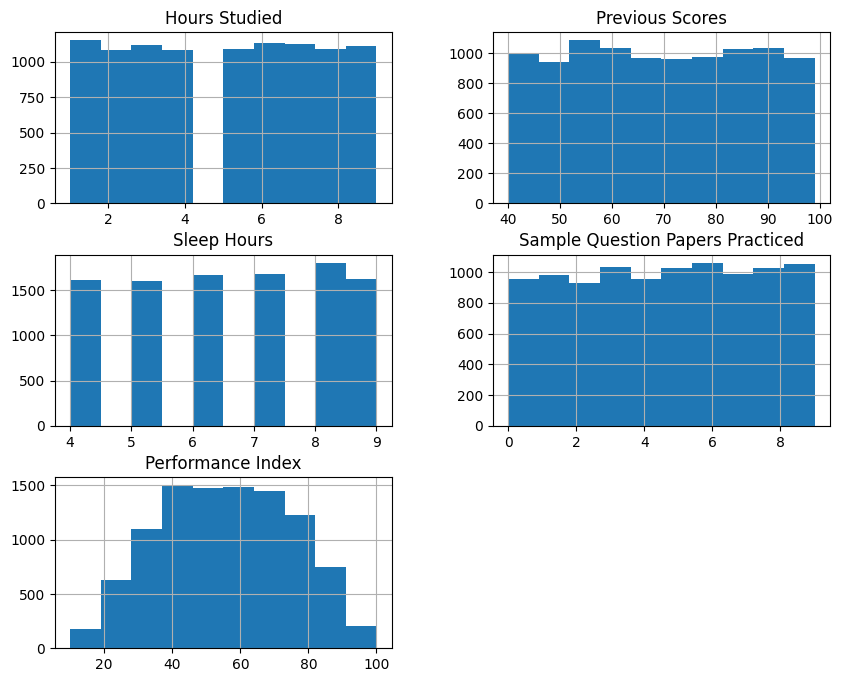

In [13]:

import matplotlib.pyplot as plt

df.hist(figsize=(10,8))

plt.show()

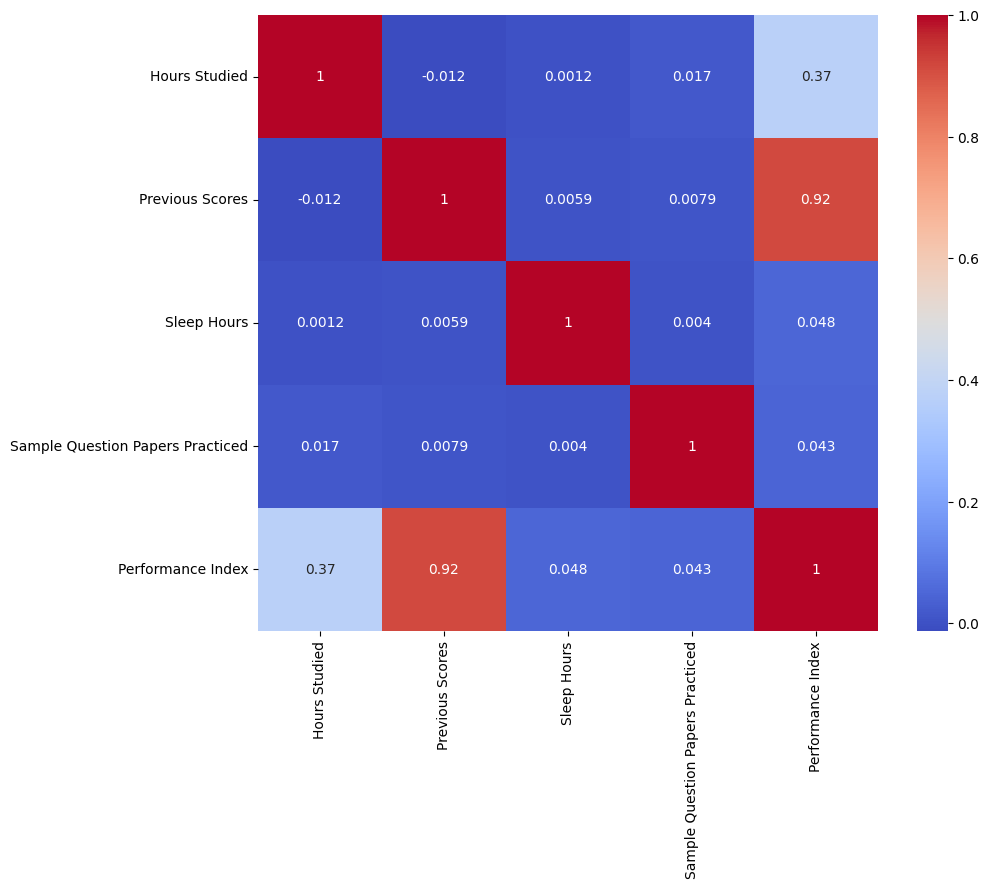

In [15]:

import seaborn as sns

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.show()

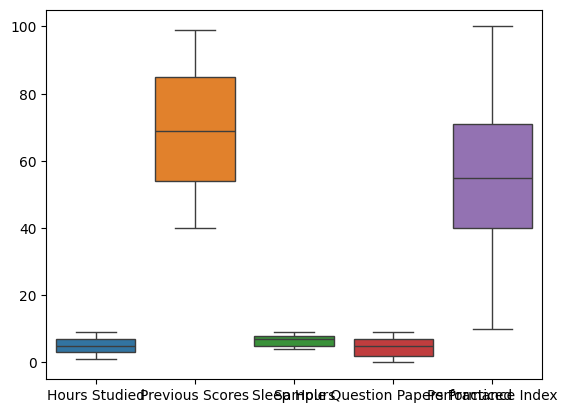

In [16]:

sns.boxplot(data=df)

plt.show()

In [19]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [20]:
df["Extracurricular Activities"].unique()

array(['Yes', 'No'], dtype=object)

In [21]:

df["Extracurricular Activities"] = df["Extracurricular Activities"].map({
"Yes": 1,
"No": 0
})

In [22]:

import pandas as pd
df = pd.read_csv("Student_Performance.csv")

In [23]:

df["Extracurricular Activities"] = df["Extracurricular Activities"].map({
"Yes": 1,
"No": 0
})

In [24]:

X = df.drop("Performance Index", axis=1)

y = df["Performance Index"]

In [25]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [26]:

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [28]:

predictions = model.predict(X_test)

In [29]:

from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, predictions))
print("MAE:", mean_absolute_error(y_test, predictions))

R2 Score: 0.9860792088401176
MAE: 1.8147207361111108


In [30]:

import pickle

pickle.dump(model, open("model.pkl", "wb"))

In [31]:

import os

print(os.listdir())

['.config', 'Student_Performance.csv', 'model.pkl', 'sample_data']


In [33]:

from google.colab import files

files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>